# 🏭 Predictive Maintenance — Model Training Pipeline

> **Pre-requisite:** Run the **Data Generator** notebook and then the **ETL Pipeline** notebook before this one. The ETL notebook saves processed train/test splits to `artifacts/`.

### Pipeline
| # | Step |
|---|------|
| 1 | Load processed data from ETL artifacts |
| 2 | Multi-Model Training (4 models) |
| 3 | Hyperparameter Tuning (RandomizedSearchCV) |
| 4 | Cross-Validation (Stratified 5-Fold) |
| 5 | Comprehensive Evaluation Suite |
| 6 | SHAP Explainability |
| 7 | Learning Curves |
| 8 | Threshold Optimization |
| 9 | Model Comparison & Selection |
| 10 | Artifact Persistence |

### Models
| Model | Role |
|-------|------|
| Logistic Regression | Linear baseline — fast, interpretable |
| Random Forest | Ensemble — robust, handles non-linearity |
| XGBoost | Gradient boosting — high accuracy, handles imbalance |
| LightGBM | Fast gradient boosting — efficient with large data |

]

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Imports
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import pandas as pd
import numpy as np
import os
import json
import time
import logging
import warnings
import joblib

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, RandomizedSearchCV,
    learning_curve
)

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

warnings.filterwarnings('ignore')

# ── Logger ───────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger('ModelTraining')

print("All imports loaded (no local modules needed).")

All imports loaded (no local modules needed).


## 0. Configuration
All tuneable parameters in one place — paths, training settings, SHAP budget, learning-curve granularity.

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Training Configuration
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TRAINING_CONFIG = {
    # Paths
    'artifacts_dir'          : 'artifacts',
    'plots_dir'              : 'artifacts/plots',

    # Training
    'random_state'           : 42,
    'cv_folds'               : 5,
    'n_iter_search'          : 30,
    'scoring_metric'         : 'f1',

    # Threshold
    'optimize_threshold'     : True,
    'threshold_metric'       : 'f1',

    # SHAP
    'compute_shap'           : True,
    'shap_sample_size'       : 500,

    # Learning Curves
    'compute_learning_curves': True,
    'learning_curve_sizes'   : [0.1, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0],
}

os.makedirs(TRAINING_CONFIG['artifacts_dir'], exist_ok=True)
os.makedirs(TRAINING_CONFIG['plots_dir'], exist_ok=True)

# ── Plot styling ─────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'primary' : '#2563EB',
    'danger'  : '#DC2626',
    'success' : '#16A34A',
    'warning' : '#F59E0B',
    'info'    : '#8B5CF6',
    'models'  : ['#2563EB', '#DC2626', '#16A34A', '#F59E0B'],
}

RS = TRAINING_CONFIG['random_state']

print(" Configuration set.")
for k, v in TRAINING_CONFIG.items():
    print(f"   {k:.<35s} {v}")

 Configuration set.
   artifacts_dir...................... artifacts
   plots_dir.......................... artifacts/plots
   random_state....................... 42
   cv_folds........................... 5
   n_iter_search...................... 30
   scoring_metric..................... f1
   optimize_threshold................. True
   threshold_metric................... f1
   compute_shap....................... True
   shap_sample_size................... 500
   compute_learning_curves............ True
   learning_curve_sizes............... [0.1, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]


## 1. Load Processed Data from ETL Artifacts
The ETL notebook already handled: validation → imputation → outliers → feature engineering → scaling → feature selection → SMOTE → train/test split.

Load the **ready-to-train** data directly.

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 1: Load processed train/test data
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("=" * 60)
print("STEP 1: Loading Processed Data from ETL Artifacts")
print("=" * 60)

pipeline_start = time.time()
artifacts_dir  = TRAINING_CONFIG['artifacts_dir']

# ── Check that all required files exist ──
required_files = [
    'X_train.csv', 'X_test.csv',
    'y_train.csv', 'y_test.csv',
    'feature_names.json',
]

missing_files = [f for f in required_files if not os.path.exists(os.path.join(artifacts_dir, f))]

if missing_files:
    raise FileNotFoundError(
        f"Missing files in '{artifacts_dir}/': {missing_files}\n"
        f" Run the Data Generator notebook first, then the ETL Pipeline notebook.\n"
        f"   The ETL notebook saves these files at the end."
    )

# ── Load train/test splits ───────────────
X_train = pd.read_csv(os.path.join(artifacts_dir, 'X_train.csv'))
X_test  = pd.read_csv(os.path.join(artifacts_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(artifacts_dir, 'y_train.csv'))['Machine_Failure']
y_test  = pd.read_csv(os.path.join(artifacts_dir, 'y_test.csv'))['Machine_Failure']

# ── Load feature names ───────────────────
with open(os.path.join(artifacts_dir, 'feature_names.json'), 'r') as f:
    feature_names = json.load(f)

print(f"  X_train       : {X_train.shape}")
print(f"  X_test        : {X_test.shape}")
print(f"  y_train       : {y_train.shape}  (failure rate: {y_train.mean():.2%})")
print(f"  y_test        : {y_test.shape}  (failure rate: {y_test.mean():.2%})")
print(f"  Features ({len(feature_names)}): {feature_names}")

print(f"\n All processed data loaded from '{artifacts_dir}/'")

STEP 1: Loading Processed Data from ETL Artifacts
  X_train       : (58047, 18)
  X_test        : (10000, 18)
  y_train       : (58047,)  (failure rate: 33.33%)
  y_test        : (10000,)  (failure rate: 3.26%)
  Features (18): ['Vib_Torque', 'Strain_Level', 'Tool_Wear_Min', 'Vibration_mm_s', 'Tool_Wear_Min_zscore', 'Vib_Risk_Level', 'Age_Vibration', 'Wear_Rate', 'Age_Stress', 'Efficiency_Proxy', 'Torque_Nm', 'Vibration_mm_s_zscore', 'Temp_Diff', 'Type_Encoded', 'Heat_Risk', 'Shift_Encoded', 'DayOfWeek', 'Process_Temp_K']

 All processed data loaded from 'artifacts/'


## 2. Model Definitions & Hyperparameter Search Spaces
Each model gets a hyperparameter grid for `RandomizedSearchCV`. Boosting models receive `scale_pos_weight` / `is_unbalance` to handle class imbalance natively.

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Model definitions + search spaces
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Class imbalance ratio for boosting models
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

print(f"  Class balance — Neg: {n_neg:,}  Pos: {n_pos:,}")
print(f"  scale_pos_weight: {scale_pos_weight:.2f}")

model_configs = {

    "Logistic Regression": {
        'model': LogisticRegression(
            max_iter=1000, random_state=RS, class_weight='balanced'
        ),
        'param_grid': {
            'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty' : ['l2'],
            'solver'  : ['lbfgs', 'liblinear'],
        },
        'description': 'Linear baseline — fast, interpretable',
    },

    "Random Forest": {
        'model': RandomForestClassifier(
            random_state=RS, class_weight='balanced', n_jobs=-1
        ),
        'param_grid': {
            'n_estimators'     : [100, 200, 300],
            'max_depth'        : [8, 12, 16, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf' : [1, 2, 4],
            'max_features'     : ['sqrt', 'log2'],
        },
        'description': 'Ensemble of decision trees — robust, handles non-linearity',
    },

    "XGBoost": {
        'model': XGBClassifier(
            use_label_encoder=False, eval_metric='logloss',
            random_state=RS, scale_pos_weight=scale_pos_weight, n_jobs=-1
        ),
        'param_grid': {
            'n_estimators'    : [100, 200, 300],
            'max_depth'       : [4, 6, 8, 10],
            'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
            'subsample'       : [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
            'min_child_weight': [1, 3, 5],
            'gamma'           : [0, 0.1, 0.3],
        },
        'description': 'Gradient boosting — high accuracy, handles imbalance',
    },

    "LightGBM": {
        'model': LGBMClassifier(
            random_state=RS, is_unbalance=True, verbose=-1, n_jobs=-1
        ),
        'param_grid': {
            'n_estimators'     : [100, 200, 300],
            'max_depth'        : [4, 6, 8, 12, -1],
            'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
            'subsample'        : [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree' : [0.7, 0.8, 0.9, 1.0],
            'num_leaves'       : [15, 31, 63, 127],
            'min_child_samples': [5, 10, 20],
        },
        'description': 'Fast gradient boosting — efficient, great with large data',
    },
}

print(f"\n {len(model_configs)} models defined.")
for name, cfg in model_configs.items():
    print(f"   • {name}: {cfg['description']}")

  Class balance — Neg: 38,698  Pos: 19,349
  scale_pos_weight: 2.00

 4 models defined.
   • Logistic Regression: Linear baseline — fast, interpretable
   • Random Forest: Ensemble of decision trees — robust, handles non-linearity
   • XGBoost: Gradient boosting — high accuracy, handles imbalance
   • LightGBM: Fast gradient boosting — efficient, great with large data


## 3. Evaluation Helpers
These are called **once per model** inside the training loop, so keeping them as lightweight functions avoids duplicating code 4×.

> Metrics · Confusion Matrix · Feature Importance · SHAP · Learning Curves · Threshold Optimization

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  3a. Compute all classification metrics
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def compute_all_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        'accuracy'    : float(accuracy_score(y_true, y_pred)),
        'f1_score'    : float(f1_score(y_true, y_pred, zero_division=0)),
        'precision'   : float(precision_score(y_true, y_pred, zero_division=0)),
        'recall'      : float(recall_score(y_true, y_pred, zero_division=0)),
        'mcc'         : float(matthews_corrcoef(y_true, y_pred)),
        'specificity' : float(recall_score(y_true, y_pred, pos_label=0, zero_division=0)),
    }
    if y_prob is not None:
        metrics['roc_auc']       = float(roc_auc_score(y_true, y_prob))
        metrics['avg_precision'] = float(average_precision_score(y_true, y_prob))
    return metrics

print(" compute_all_metrics defined.")

 compute_all_metrics defined.


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  3b. Confusion matrix plot
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_confusion_matrix(y_true, y_pred, model_name, plots_dir):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Failure'],
        yticklabels=['Normal', 'Failure'],
        annot_kws={'size': 16}, ax=ax,
    )
    ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=13, fontweight='bold')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=15, fontweight='bold', pad=15)

    tn, fp, fn, tp = cm.ravel()
    ax.text(
        2.4, 0.5, f'TN={tn:,}  FP={fp:,}\nFN={fn:,}  TP={tp:,}',
        fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    )

    plt.tight_layout()
    filepath = os.path.join(plots_dir, f'confusion_matrix_{model_name.replace(" ", "_").lower()}.png')
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filepath}")
    plt.show(); plt.close(fig)
    return cm

print(" plot_confusion_matrix defined.")

 plot_confusion_matrix defined.


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  3c. Feature importance plot
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_feature_importance(model, feat_names, model_name, plots_dir, top_n=15):
    if not hasattr(model, 'feature_importances_'):
        logger.warning(f"  {model_name} has no feature_importances_ — skipping")
        return None

    importance = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=True)
    top = importance.tail(top_n)

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(range(len(top)), top.values, color=COLORS['primary'], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=11)
    ax.set_xlabel('Importance Score', fontsize=13, fontweight='bold')
    ax.set_title(f'Top {top_n} Feature Importance — {model_name}', fontsize=15, fontweight='bold', pad=15)

    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    filepath = os.path.join(plots_dir, f'feature_importance_{model_name.replace(" ", "_").lower()}.png')
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filepath}")
    plt.show(); plt.close(fig)
    return importance

print(" plot_feature_importance defined.")

 plot_feature_importance defined.


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  3d. SHAP values
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def compute_shap_values(model, X_sample, feat_names, model_name, plots_dir):
    print(f"  Computing SHAP values for {model_name}...")
    try:
        if isinstance(model, (RandomForestClassifier, XGBClassifier, LGBMClassifier)):
            explainer = shap.TreeExplainer(model)
        else:
            explainer = shap.LinearExplainer(model, X_sample)

        shap_values = explainer.shap_values(X_sample)

        shap_vals = (
            shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1
            else (shap_values[0] if isinstance(shap_values, list) else shap_values)
        )

        # ── Beeswarm summary ────────────
        fig, ax = plt.subplots(figsize=(12, 8))
        shap.summary_plot(shap_vals, X_sample, feature_names=feat_names,
                          show=False, max_display=15, plot_size=None)
        plt.title(f'SHAP Summary — {model_name}', fontsize=15, fontweight='bold', pad=15)
        plt.tight_layout()
        fp = os.path.join(plots_dir, f'shap_summary_{model_name.replace(" ", "_").lower()}.png')
        fig.savefig(fp, dpi=150, bbox_inches='tight')
        print(f"  Saved: {fp}")
        plt.show(); plt.close(fig)

        # ── Bar summary ─────────────────
        fig, ax = plt.subplots(figsize=(10, 8))
        shap.summary_plot(shap_vals, X_sample, feature_names=feat_names,
                          plot_type='bar', show=False, max_display=15, plot_size=None)
        plt.title(f'SHAP Feature Importance — {model_name}', fontsize=15, fontweight='bold', pad=15)
        plt.tight_layout()
        fp = os.path.join(plots_dir, f'shap_bar_{model_name.replace(" ", "_").lower()}.png')
        fig.savefig(fp, dpi=150, bbox_inches='tight')
        print(f"  Saved: {fp}")
        plt.show(); plt.close(fig)

        # ── Save raw values ─────────────
        shap_df = pd.DataFrame(shap_vals, columns=feat_names)
        fp = os.path.join(plots_dir, f'shap_values_{model_name.replace(" ", "_").lower()}.csv')
        shap_df.to_csv(fp, index=False)

        print(f"  SHAP computation complete for {model_name}")
        return shap_vals

    except Exception as e:
        logger.warning(f"  SHAP failed for {model_name}: {e}")
        return None

print(" compute_shap_values defined.")

 compute_shap_values defined.


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  3e. Learning curves
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def plot_learning_curves(model, X_tr, y_tr, model_name, plots_dir):
    print(f"  Computing learning curves for {model_name}...")
    try:
        train_sizes, train_scores, val_scores = learning_curve(
            model, X_tr, y_tr,
            train_sizes=TRAINING_CONFIG['learning_curve_sizes'],
            cv=3, scoring='f1', n_jobs=-1,
            random_state=RS,
        )

        t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
        v_mean, v_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

        fig, ax = plt.subplots(figsize=(10, 7))
        ax.plot(train_sizes, t_mean, color=COLORS['primary'], linewidth=2.5, label='Training Score')
        ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color=COLORS['primary'])
        ax.plot(train_sizes, v_mean, color=COLORS['danger'], linewidth=2.5, label='Validation Score')
        ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color=COLORS['danger'])

        ax.set_xlabel('Training Set Size', fontsize=13, fontweight='bold')
        ax.set_ylabel('F1 Score', fontsize=13, fontweight='bold')
        ax.set_title(f'Learning Curves — {model_name}', fontsize=15, fontweight='bold', pad=15)
        ax.legend(fontsize=12, loc='lower right', framealpha=0.9)
        ax.grid(True, alpha=0.3); ax.set_ylim([0, 1.05])
        plt.tight_layout()

        fp = os.path.join(plots_dir, f'learning_curve_{model_name.replace(" ", "_").lower()}.png')
        fig.savefig(fp, dpi=150, bbox_inches='tight')
        print(f"  Saved: {fp}")
        plt.show(); plt.close(fig)

    except Exception as e:
        logger.warning(f"  Learning curve failed for {model_name}: {e}")

print(" plot_learning_curves defined.")

 plot_learning_curves defined.


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  3f. Threshold optimization
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def optimize_threshold(y_true, y_prob, model_name, plots_dir):
    thresholds    = np.arange(0.1, 0.9, 0.01)
    f1_arr        = np.array([f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds])
    precision_arr = np.array([precision_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds])
    recall_arr    = np.array([recall_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds])

    best_idx       = f1_arr.argmax()
    best_threshold = float(thresholds[best_idx])
    best_f1        = float(f1_arr[best_idx])
    default_f1     = float(f1_arr[np.argmin(np.abs(thresholds - 0.5))])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(thresholds, f1_arr,        label='F1 Score',  color=COLORS['primary'], linewidth=2.5)
    ax.plot(thresholds, precision_arr, label='Precision', color=COLORS['success'], linewidth=2, linestyle='--')
    ax.plot(thresholds, recall_arr,    label='Recall',    color=COLORS['danger'],  linewidth=2, linestyle='--')
    ax.axvline(x=best_threshold, color=COLORS['warning'], linewidth=2, linestyle=':',
               label=f'Best Threshold = {best_threshold:.2f}')
    ax.axvline(x=0.5, color='gray', linewidth=1.5, linestyle=':', alpha=0.5, label='Default (0.5)')

    ax.set_xlabel('Classification Threshold', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title(f'Threshold Optimization — {model_name}', fontsize=15, fontweight='bold', pad=15)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3); ax.set_xlim([0.1, 0.9]); ax.set_ylim([0, 1.05])
    plt.tight_layout()

    fp = os.path.join(plots_dir, f'threshold_optimization_{model_name.replace(" ", "_").lower()}.png')
    fig.savefig(fp, dpi=150, bbox_inches='tight')
    print(f"  Saved: {fp}")
    plt.show(); plt.close(fig)

    return {
        'best_threshold': best_threshold,
        'best_f1'       : best_f1,
        'default_f1'    : default_f1,
        'improvement'   : float(best_f1 - default_f1),
    }

print(" optimize_threshold defined.")

 optimize_threshold defined.


## 4. Training Loop
For **each of the 4 models**:
1. Hyperparameter-tune with `RandomizedSearchCV`
2. Cross-validate the tuned model (Stratified 5-Fold)
3. Train on full training set & predict on test set
4. Compute all metrics
5. Generate confusion matrix, feature importance, threshold optimization, learning curves, and SHAP plots


STEP 2: Model Training & Evaluation

  MODEL 1/4: Logistic Regression
  Linear baseline — fast, interpretable
  Tuning Logistic Regression...


    Best Score : 0.5016
    Best Params: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
  Cross-validating Logistic Regression...
    f1          : 0.5024 ± 0.0057
    accuracy    : 0.6248 ± 0.0017
    roc_auc     : 0.6629 ± 0.0040
    precision   : 0.4502 ± 0.0026
    recall      : 0.5684 ± 0.0107

  Test Set Results for Logistic Regression:
    accuracy            : 0.6560
    f1_score            : 0.1097
    precision           : 0.0599
    recall              : 0.6503
    mcc                 : 0.1138
    specificity         : 0.6562
    roc_auc             : 0.6832
    avg_precision       : 0.0731
    Training Time       : 19.7s

  Classification Report:

              precision    recall  f1-score   support

      Normal     0.9824    0.6562    0.7868      9674
     Failure     0.0599    0.6503    0.1097       326

    accuracy                         0.6560     10000
   macro avg     0.5211    0.6532    0.4483     10000
weighted avg     0.9523    0.6560    0.7647     10000

 

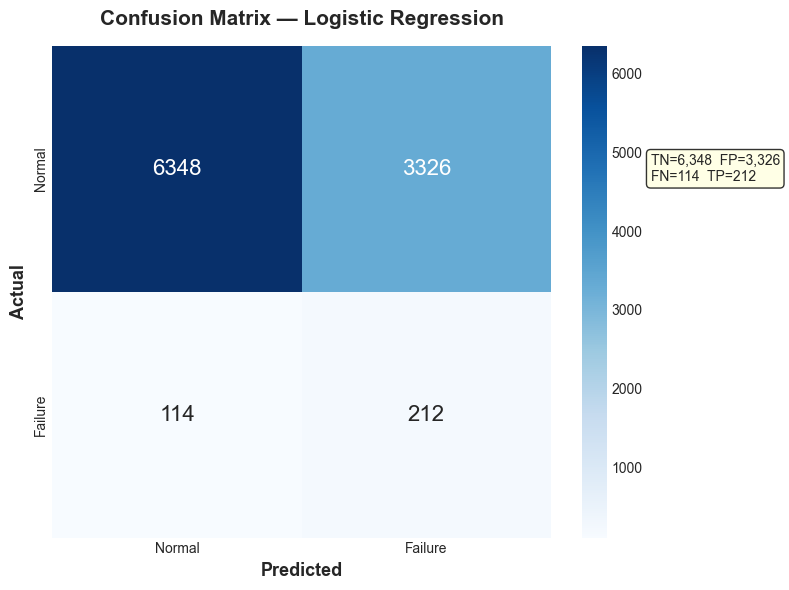

17:21:36 | WARNING  |   Logistic Regression has no feature_importances_ — skipping


  Saved: artifacts/plots\threshold_optimization_logistic_regression.png


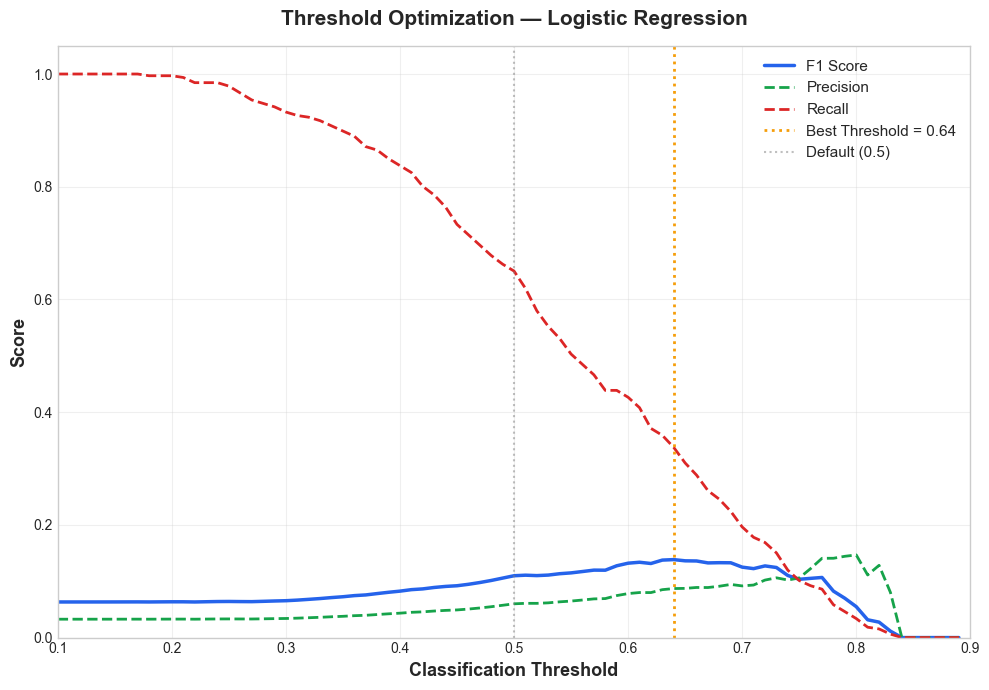


  Optimal Threshold: 0.64 (F1: 0.1384, improvement: +0.0286)
  Computing learning curves for Logistic Regression...
  Saved: artifacts/plots\learning_curve_logistic_regression.png


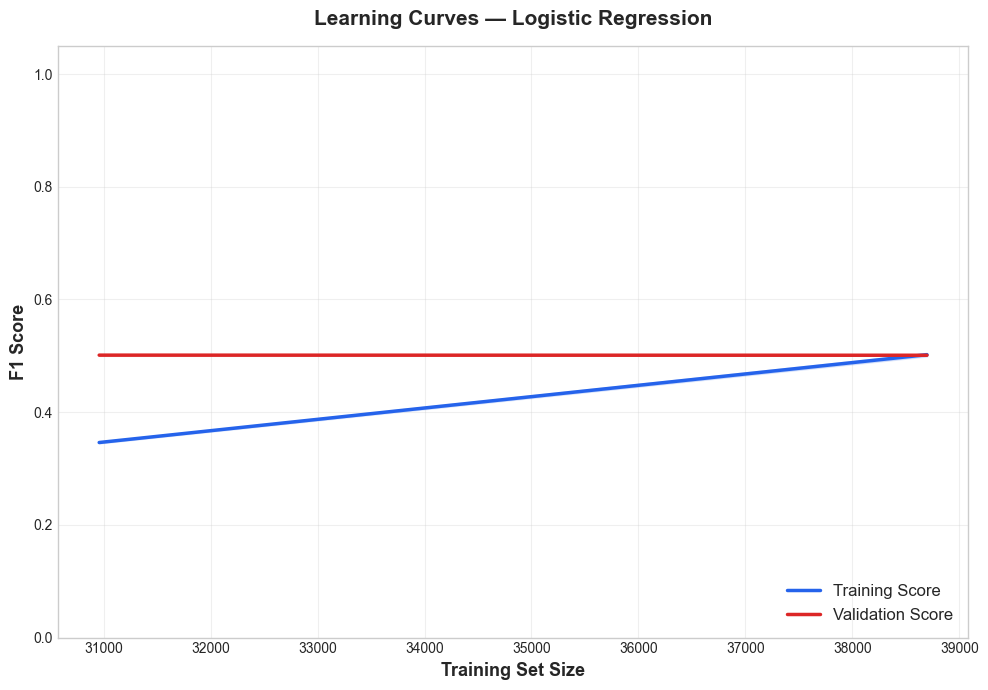

  Computing SHAP values for Logistic Regression...
  Saved: artifacts/plots\shap_summary_logistic_regression.png


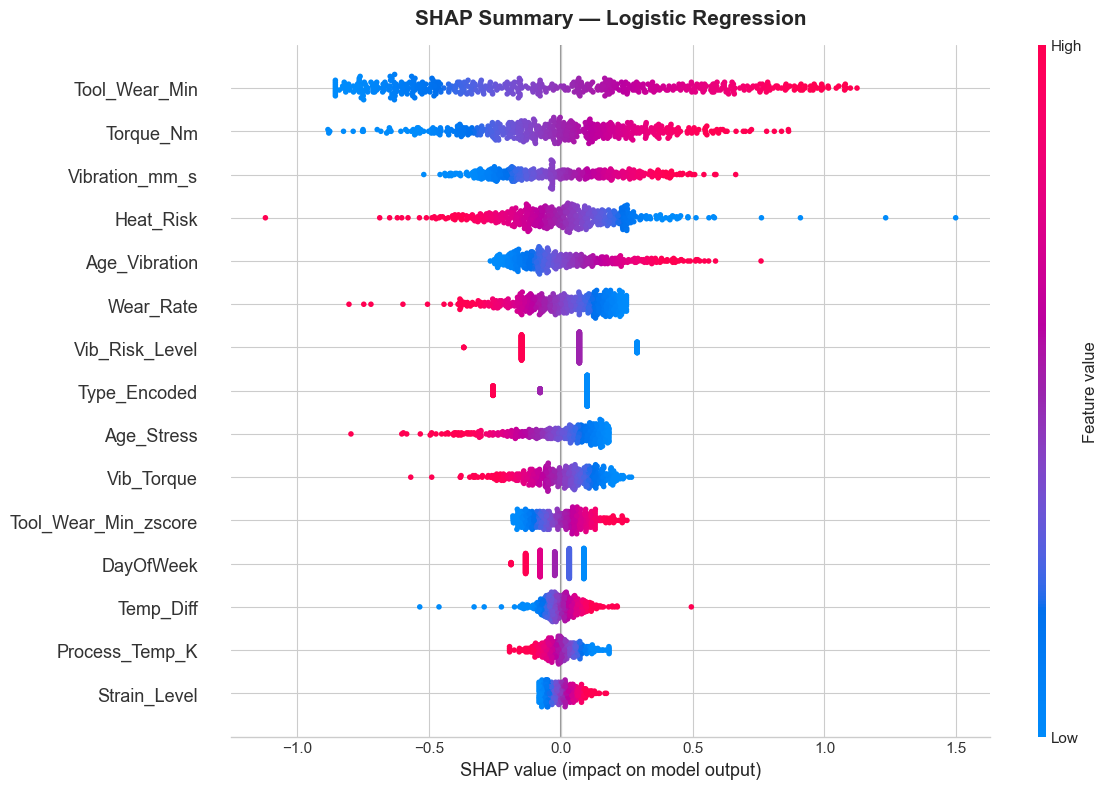

  Saved: artifacts/plots\shap_bar_logistic_regression.png


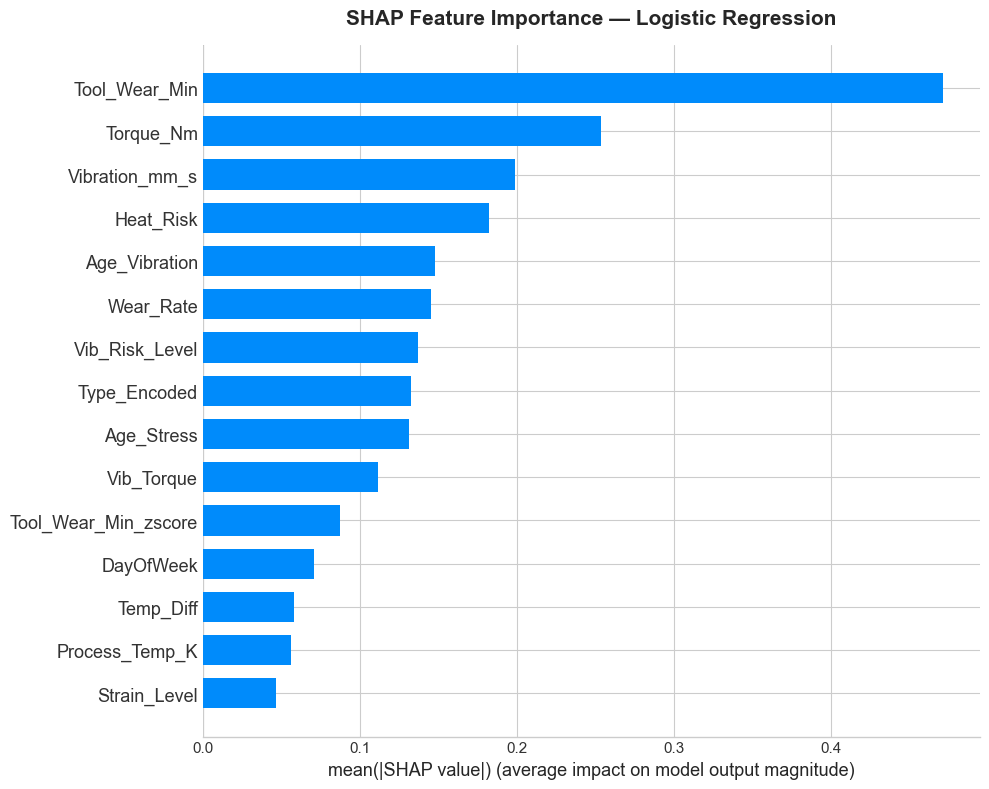

  SHAP computation complete for Logistic Regression

  MODEL 2/4: Random Forest
  Ensemble of decision trees — robust, handles non-linearity
  Tuning Random Forest...
    Best Score : 0.9519
    Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  Cross-validating Random Forest...
    f1          : 0.9599 ± 0.0019
    accuracy    : 0.9739 ± 0.0012
    roc_auc     : 0.9965 ± 0.0003
    precision   : 0.9853 ± 0.0026
    recall      : 0.9358 ± 0.0033

  Test Set Results for Random Forest:
    accuracy            : 0.9627
    f1_score            : 0.0460
    precision           : 0.1385
    recall              : 0.0276
    mcc                 : 0.0482
    specificity         : 0.9942
    roc_auc             : 0.6166
    avg_precision       : 0.0625
    Training Time       : 1881.4s

  Classification Report:

              precision    recall  f1-score   support

      Normal     0.9681    0.9942    0.9810      9674
 

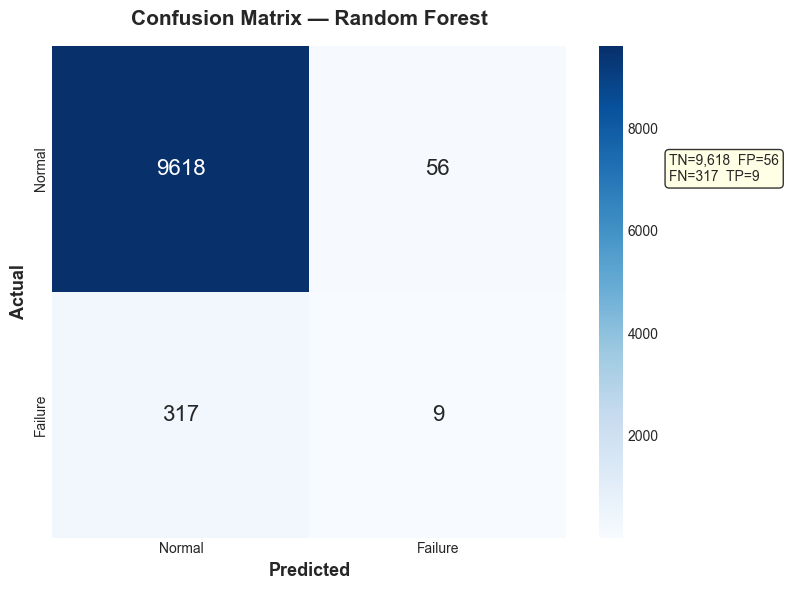

  Saved: artifacts/plots\feature_importance_random_forest.png


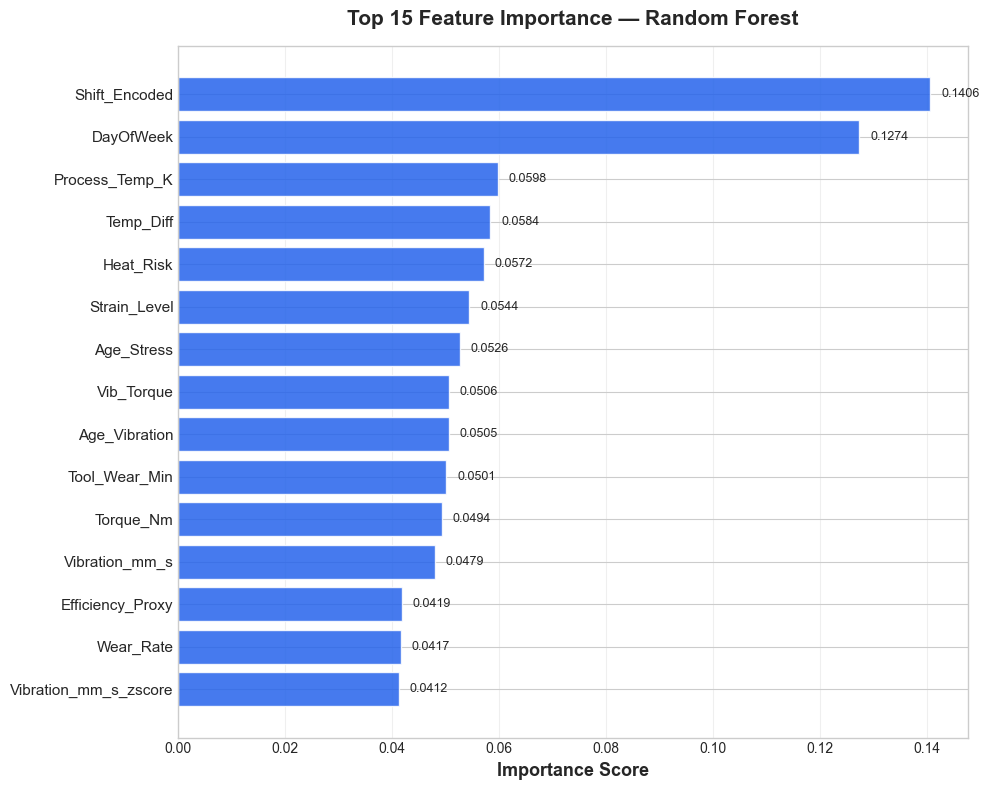

  Saved: artifacts/plots\threshold_optimization_random_forest.png


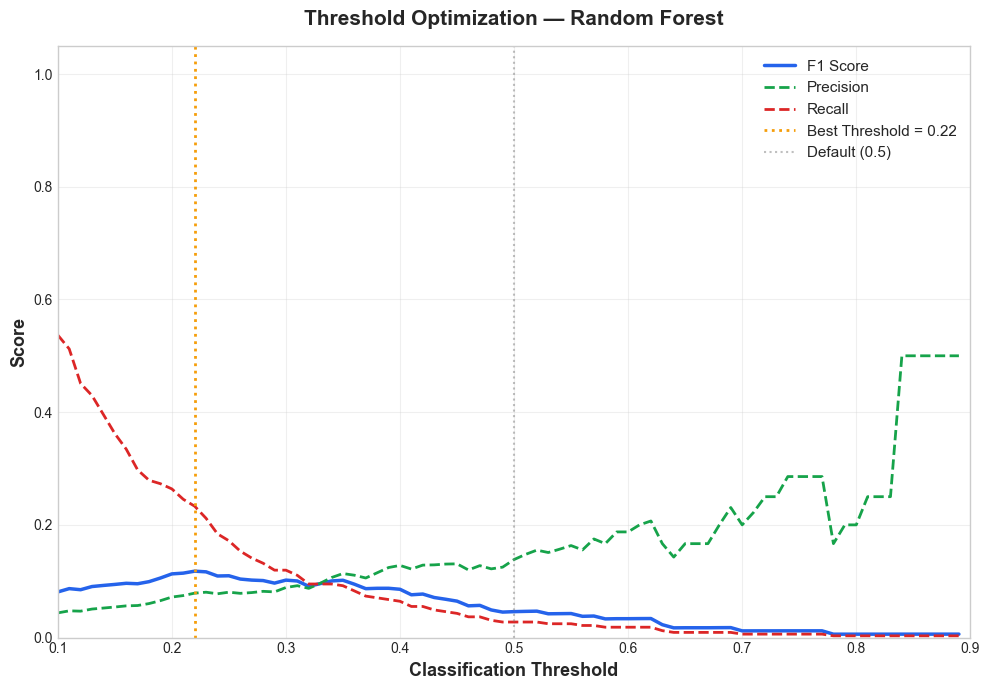


  Optimal Threshold: 0.22 (F1: 0.1178, improvement: +0.0718)
  Computing learning curves for Random Forest...
  Saved: artifacts/plots\learning_curve_random_forest.png


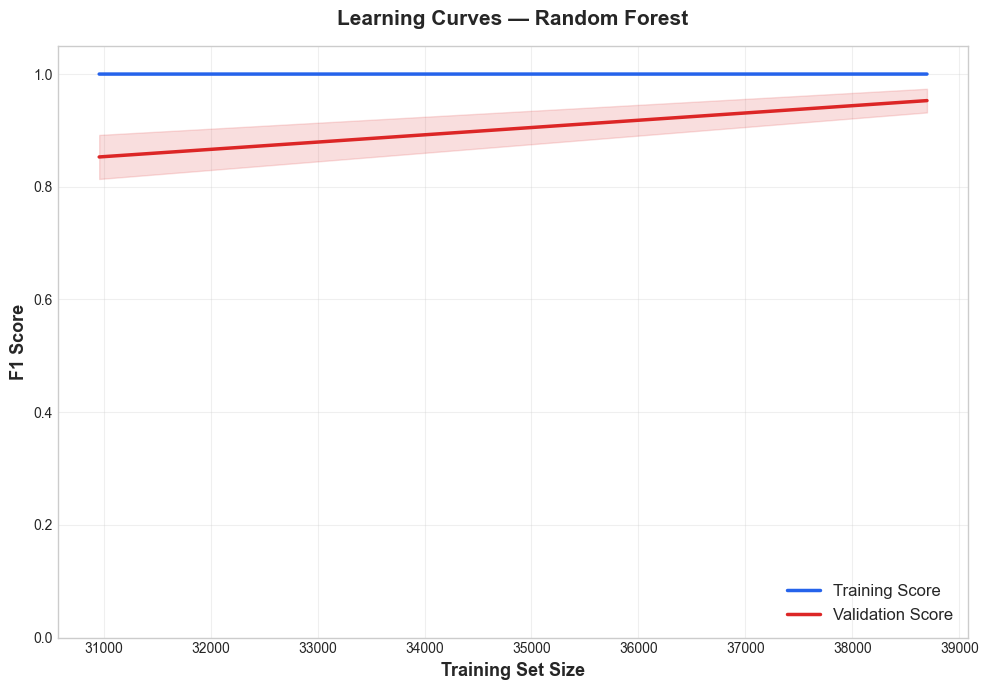

  Computing SHAP values for Random Forest...
  Saved: artifacts/plots\shap_summary_random_forest.png


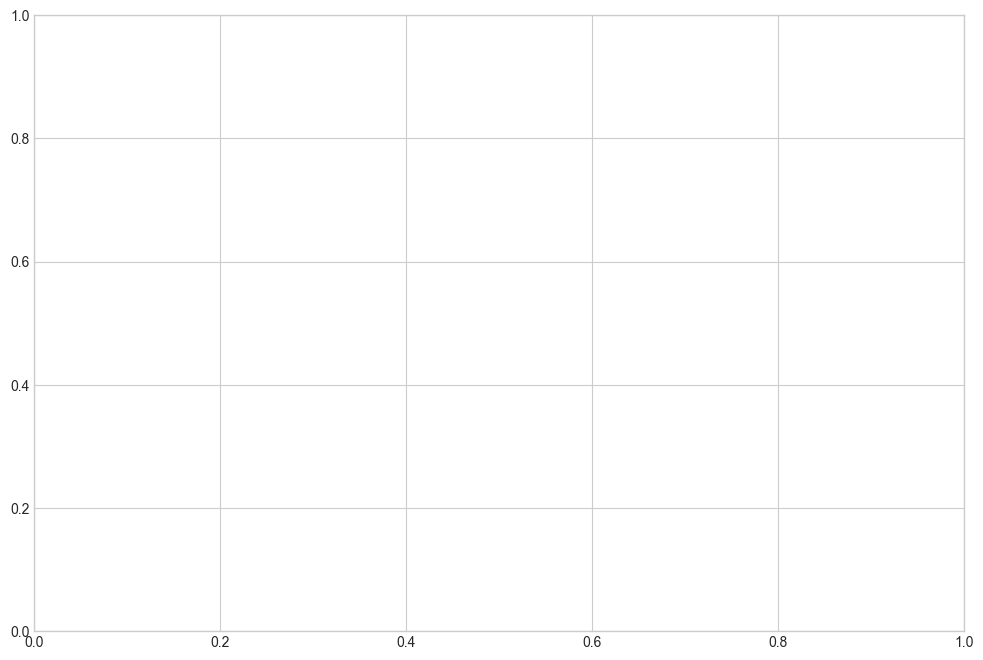

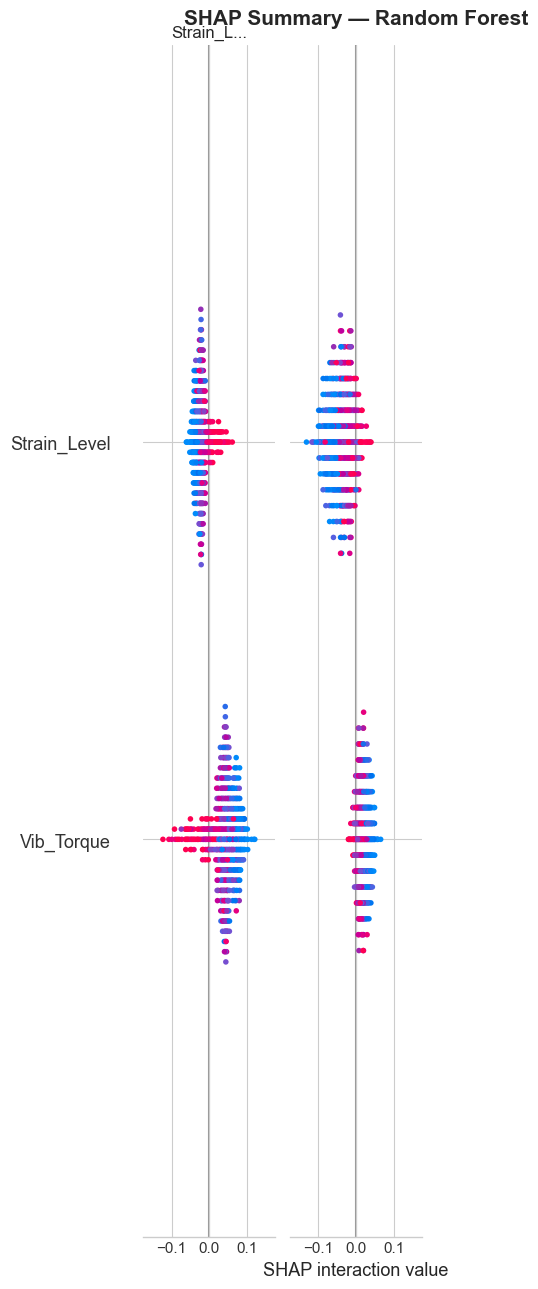

  Saved: artifacts/plots\shap_bar_random_forest.png


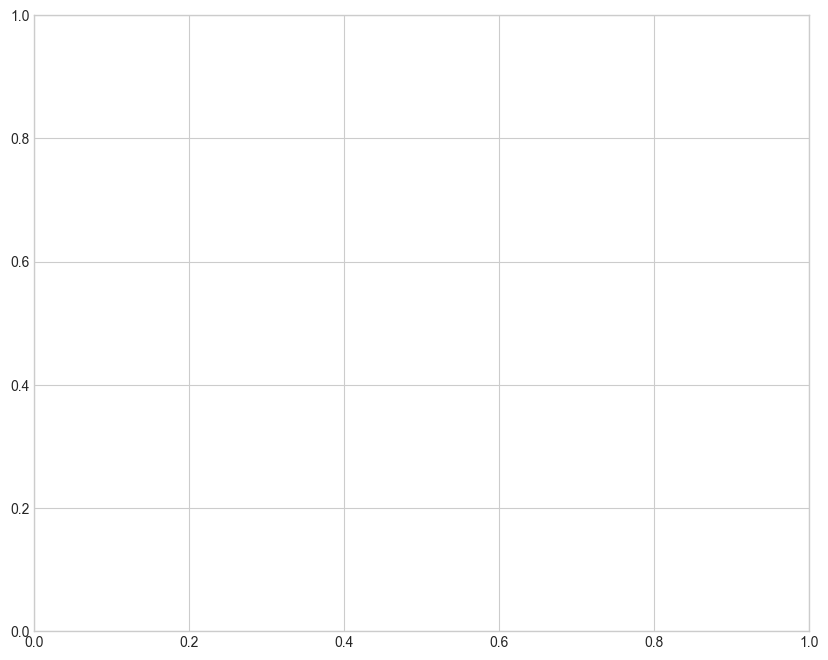

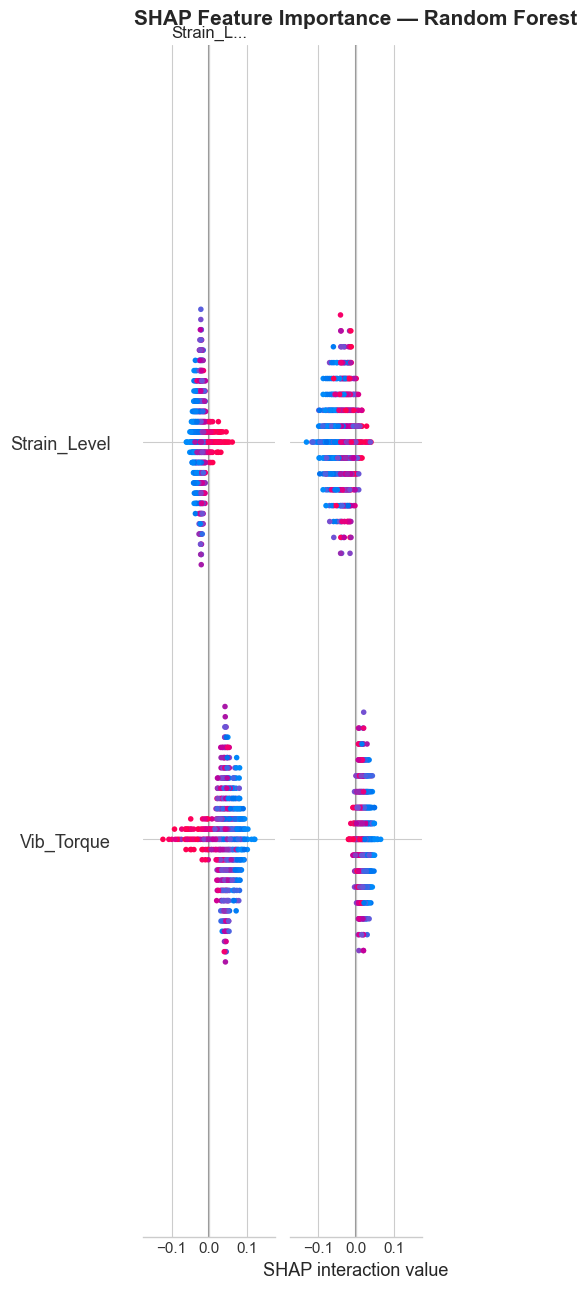

17:58:53 | WARNING  |   SHAP failed for Random Forest: Must pass 2-d input. shape=(500, 18, 2)



  MODEL 3/4: XGBoost
  Gradient boosting — high accuracy, handles imbalance
  Tuning XGBoost...
    Best Score : 0.9561
    Best Params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 1.0}
  Cross-validating XGBoost...
    f1          : 0.9625 ± 0.0029
    accuracy    : 0.9756 ± 0.0018
    roc_auc     : 0.9917 ± 0.0008
    precision   : 0.9839 ± 0.0021
    recall      : 0.9421 ± 0.0065

  Test Set Results for XGBoost:
    accuracy            : 0.9617
    f1_score            : 0.0304
    precision           : 0.0870
    recall              : 0.0184
    mcc                 : 0.0255
    specificity         : 0.9935
    roc_auc             : 0.5934
    avg_precision       : 0.0512
    Training Time       : 158.7s

  Classification Report:

              precision    recall  f1-score   support

      Normal     0.9678    0.9935    0.9805      9674
     Failure     0.0870    0.0184    0.0304       326

  

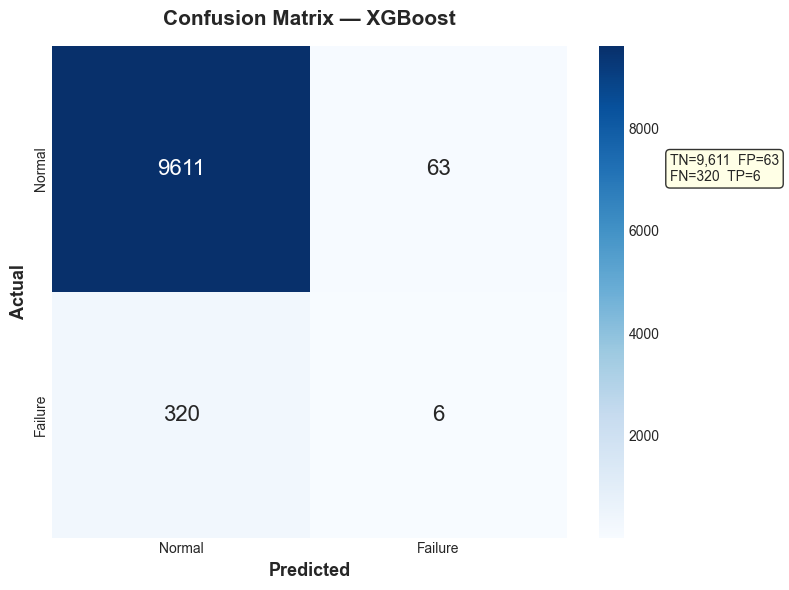

  Saved: artifacts/plots\feature_importance_xgboost.png


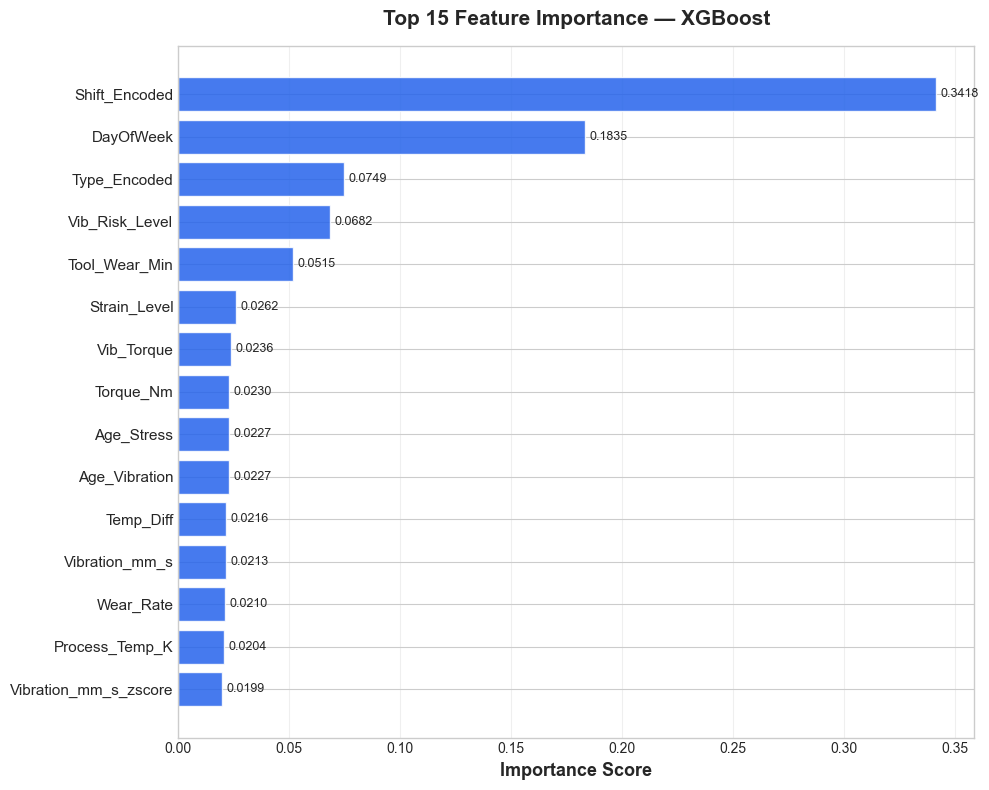

  Saved: artifacts/plots\threshold_optimization_xgboost.png


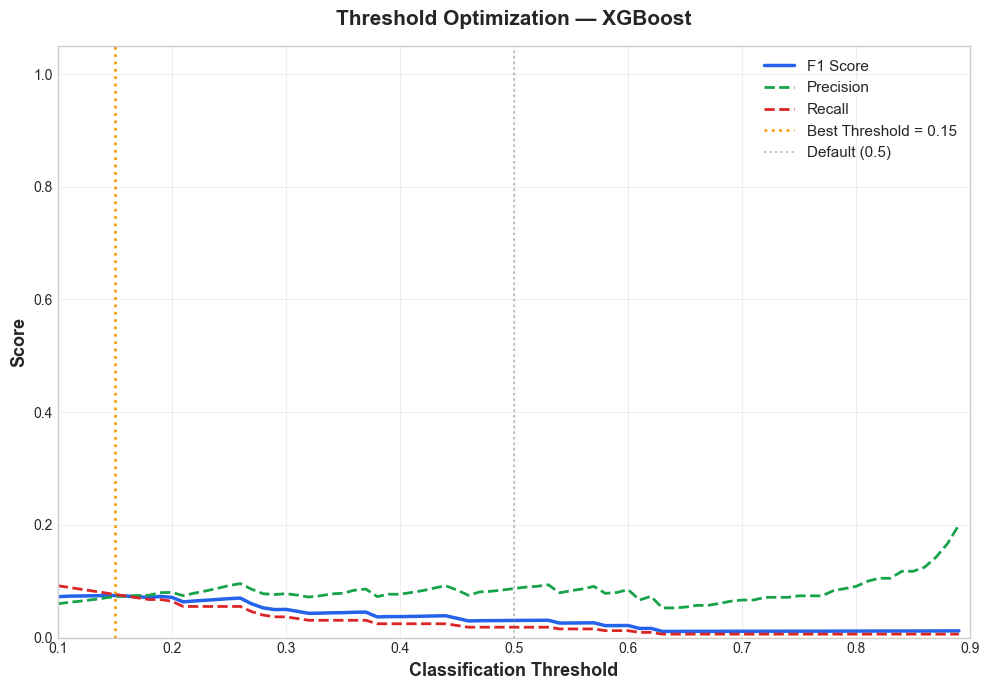


  Optimal Threshold: 0.15 (F1: 0.0747, improvement: +0.0444)
  Computing learning curves for XGBoost...
  Saved: artifacts/plots\learning_curve_xgboost.png


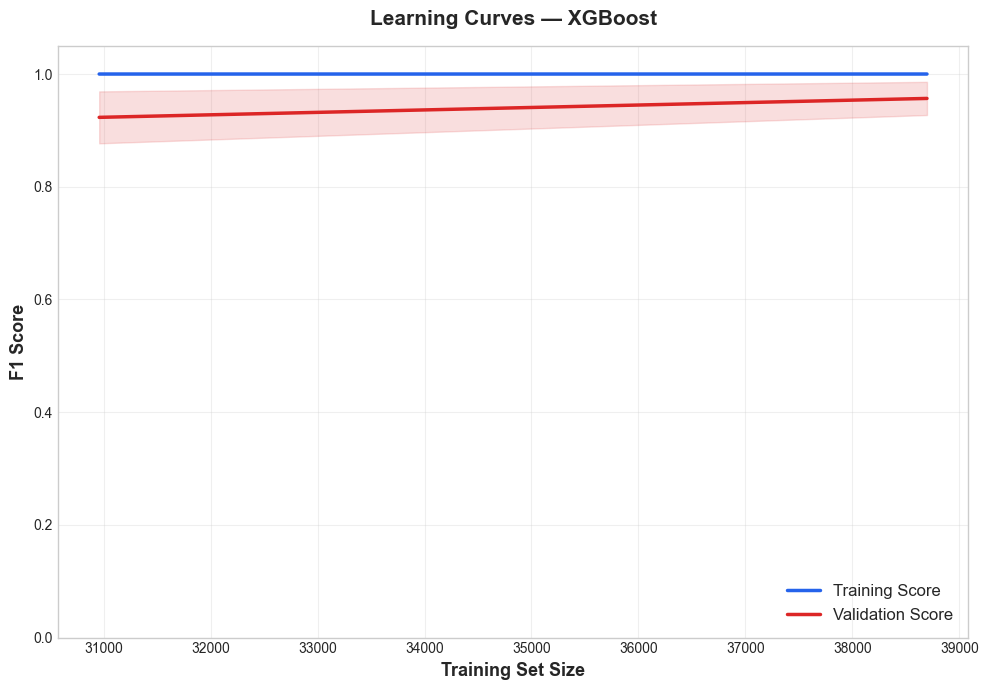

  Computing SHAP values for XGBoost...
  Saved: artifacts/plots\shap_summary_xgboost.png


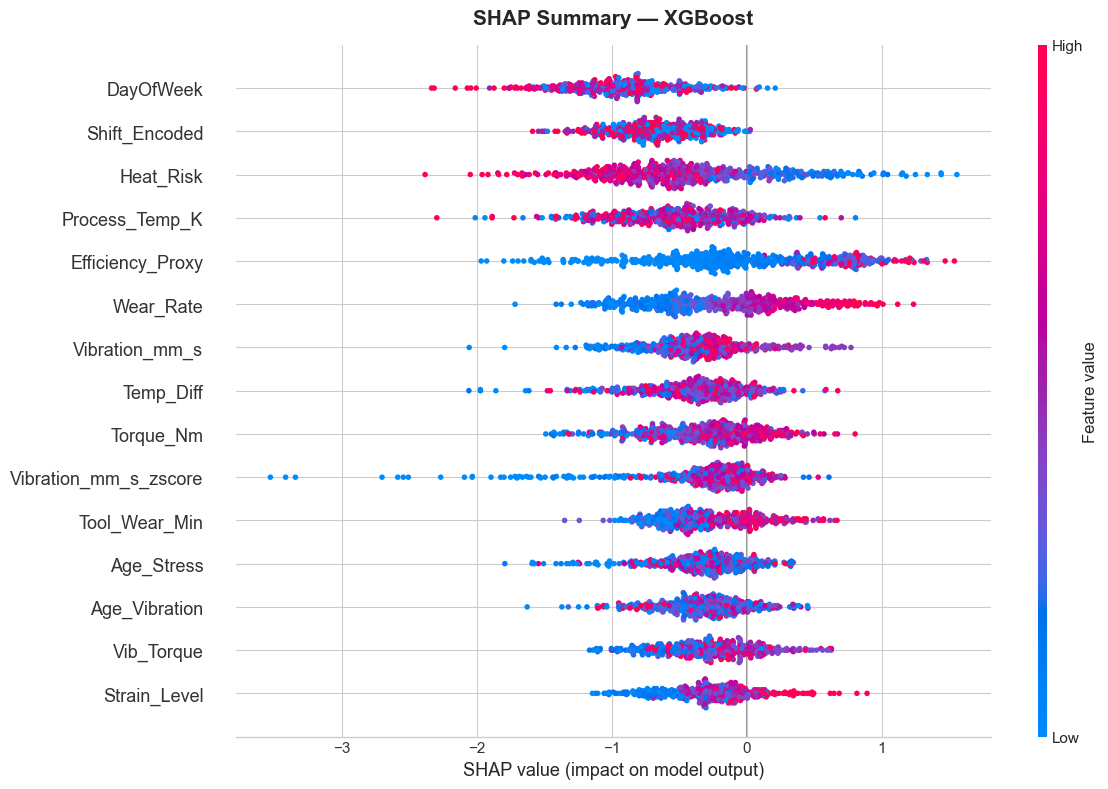

  Saved: artifacts/plots\shap_bar_xgboost.png


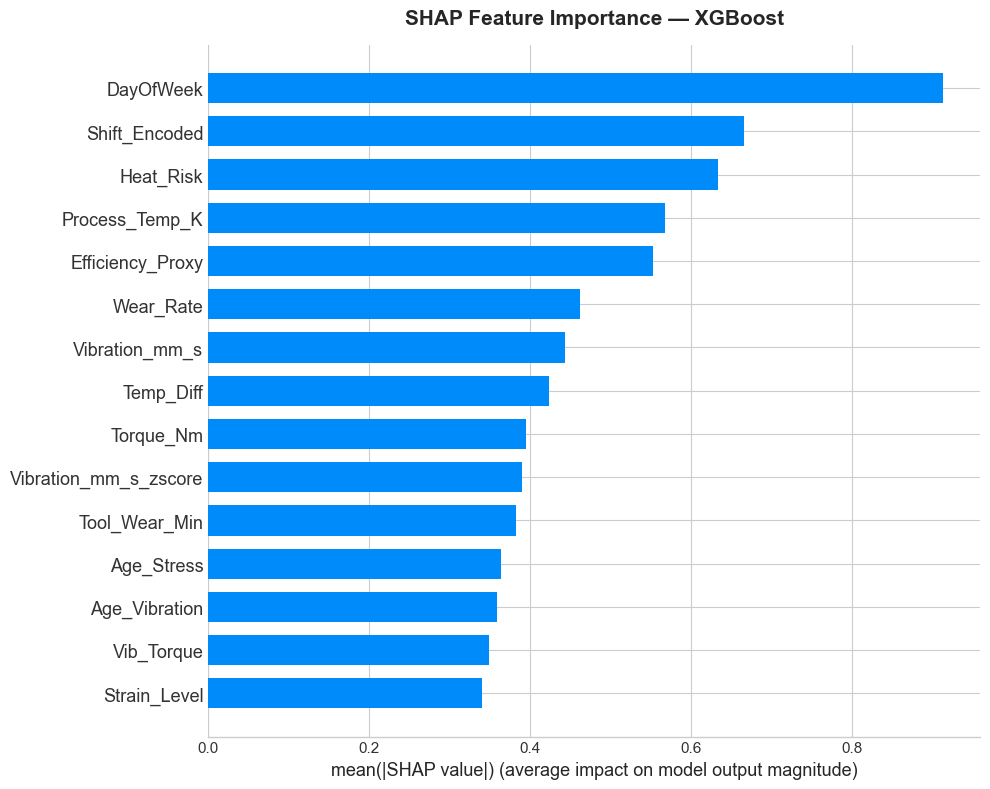

  SHAP computation complete for XGBoost

  MODEL 4/4: LightGBM
  Fast gradient boosting — efficient, great with large data
  Tuning LightGBM...
    Best Score : 0.9400
    Best Params: {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 200, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
  Cross-validating LightGBM...
    f1          : 0.9428 ± 0.0028
    accuracy    : 0.9631 ± 0.0017
    roc_auc     : 0.9837 ± 0.0007
    precision   : 0.9758 ± 0.0027
    recall      : 0.9120 ± 0.0061

  Test Set Results for LightGBM:
    accuracy            : 0.9573
    f1_score            : 0.0656
    precision           : 0.1145
    recall              : 0.0460
    mcc                 : 0.0531
    specificity         : 0.9880
    roc_auc             : 0.6213
    avg_precision       : 0.0578
    Training Time       : 149.9s

  Classification Report:

              precision    recall  f1-score   support

      Normal     0.9685    0.9880    0.9782      9674


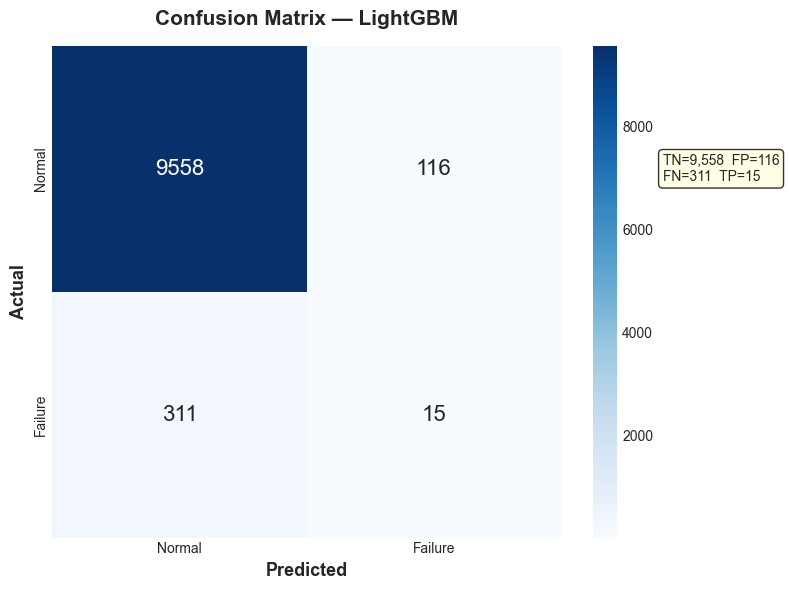

  Saved: artifacts/plots\feature_importance_lightgbm.png


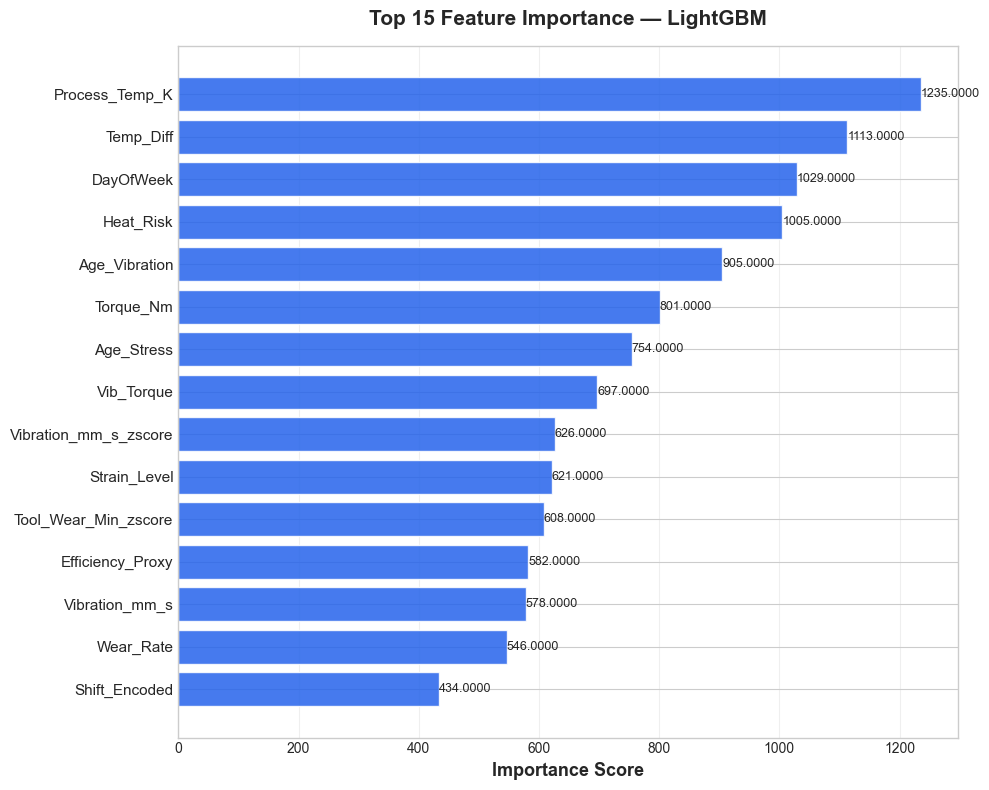

  Saved: artifacts/plots\threshold_optimization_lightgbm.png


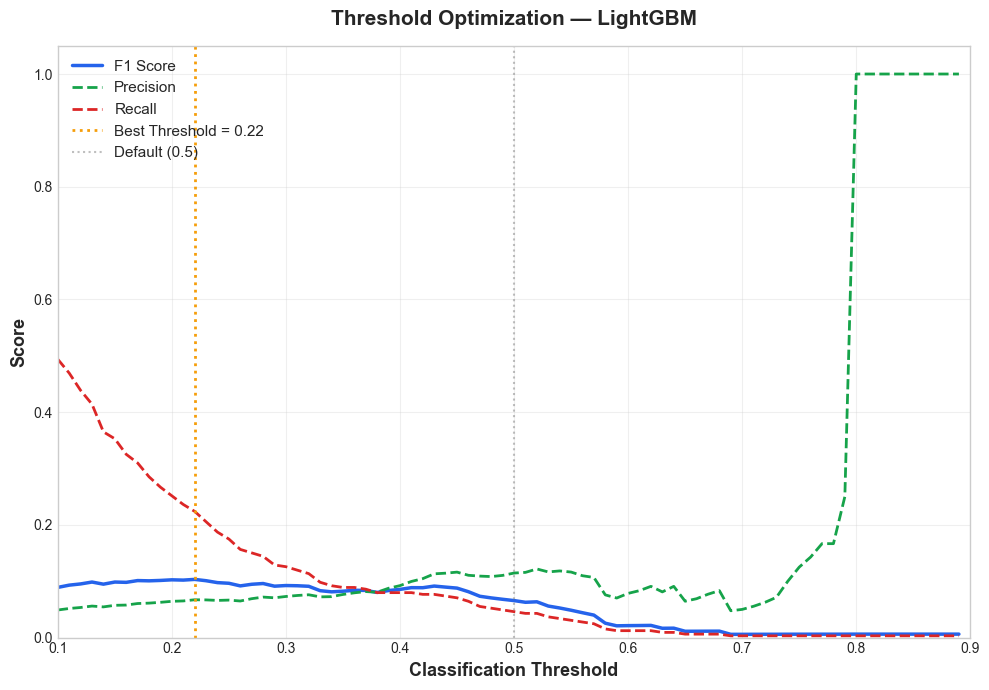


  Optimal Threshold: 0.22 (F1: 0.1033, improvement: +0.0376)
  Computing learning curves for LightGBM...
  Saved: artifacts/plots\learning_curve_lightgbm.png


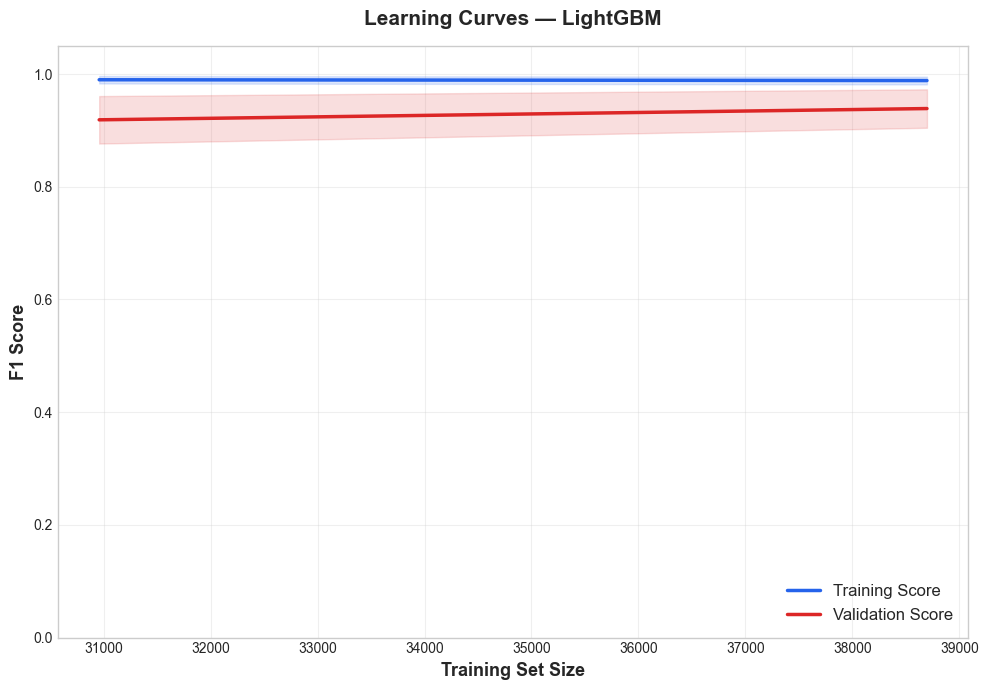

  Computing SHAP values for LightGBM...
  Saved: artifacts/plots\shap_summary_lightgbm.png


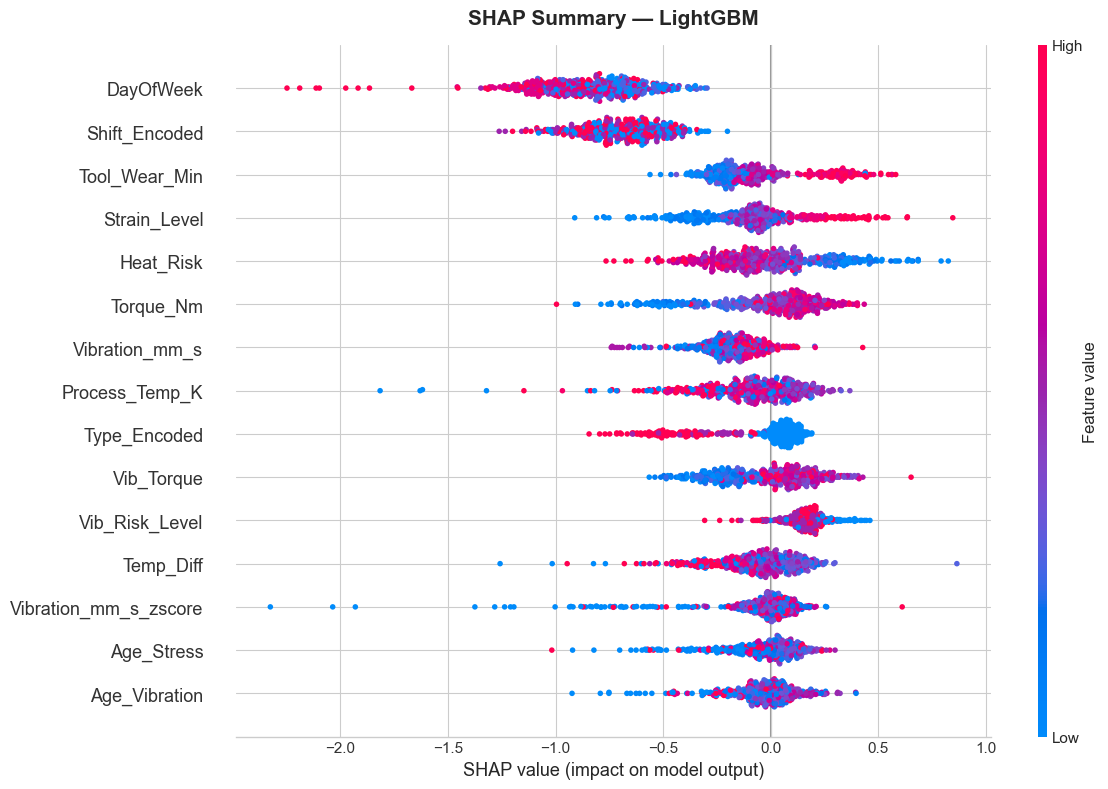

  Saved: artifacts/plots\shap_bar_lightgbm.png


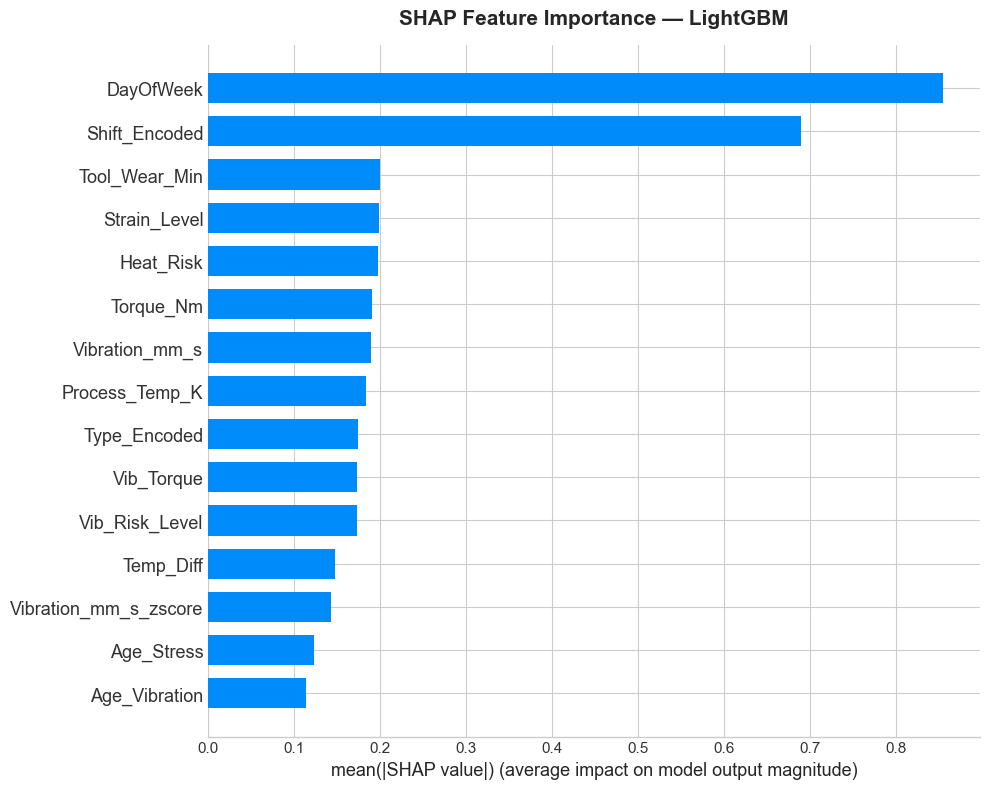

  SHAP computation complete for LightGBM

 All 4 models trained & evaluated.


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  STEP 2: Train & Evaluate Every Model
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "=" * 60)
print("STEP 2: Model Training & Evaluation")
print("=" * 60)

plots_dir       = TRAINING_CONFIG['plots_dir']
all_results     = {}
best_model      = None
best_model_name = ""
best_score      = 0

for model_idx, (name, cfg) in enumerate(model_configs.items(), 1):

    print("\n" + "=" * 60)
    print(f"  MODEL {model_idx}/{len(model_configs)}: {name}")
    print(f"  {cfg['description']}")
    print("=" * 60)

    start_time = time.time()

    # ─────────────────────────────────────
    # 4a. Hyperparameter Tuning
    # ─────────────────────────────────────
    print(f"  Tuning {name}...")

    cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RS)

    search = RandomizedSearchCV(
        estimator           = cfg['model'],
        param_distributions = cfg['param_grid'],
        n_iter              = TRAINING_CONFIG['n_iter_search'],
        scoring             = TRAINING_CONFIG['scoring_metric'],
        cv                  = cv_tune,
        random_state        = RS,
        n_jobs              = -1,
        verbose             = 0,
    )
    search.fit(X_train, y_train)

    tuned_model = search.best_estimator_
    best_params = search.best_params_
    print(f"    Best Score : {search.best_score_:.4f}")
    print(f"    Best Params: {best_params}")

    # ─────────────────────────────────────
    # 4b. Cross-Validation (tuned model)
    # ─────────────────────────────────────
    print(f"  Cross-validating {name}...")

    cv_eval    = StratifiedKFold(n_splits=TRAINING_CONFIG['cv_folds'], shuffle=True, random_state=RS)
    cv_results = {}

    for metric in ['f1', 'accuracy', 'roc_auc', 'precision', 'recall']:
        scores = cross_val_score(tuned_model, X_train, y_train, cv=cv_eval, scoring=metric, n_jobs=-1)
        cv_results[metric] = {
            'mean'  : float(scores.mean()),
            'std'   : float(scores.std()),
            'scores': scores.tolist(),
        }
        print(f"    {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}")

    # ─────────────────────────────────────
    # 4c. Final Training & Prediction
    # ─────────────────────────────────────
    tuned_model.fit(X_train, y_train)
    y_pred = tuned_model.predict(X_test)

    y_prob = None
    if hasattr(tuned_model, 'predict_proba'):
        y_prob = tuned_model.predict_proba(X_test)[:, 1]

    # ─────────────────────────────────────
    # 4d. Metrics
    # ─────────────────────────────────────
    metrics    = compute_all_metrics(y_test, y_pred, y_prob)
    train_time = time.time() - start_time

    print(f"\n  Test Set Results for {name}:")
    for mname, mval in metrics.items():
        print(f"    {mname:20s}: {mval:.4f}")
    print(f"    {'Training Time':20s}: {train_time:.1f}s")

    print(f"\n  Classification Report:")
    print("\n" + classification_report(y_test, y_pred, target_names=['Normal', 'Failure'], digits=4))

    # ─────────────────────────────────────
    # 4e. Confusion Matrix
    # ─────────────────────────────────────
    cm = plot_confusion_matrix(y_test, y_pred, name, plots_dir)

    # ─────────────────────────────────────
    # 4f. Feature Importance
    # ─────────────────────────────────────
    importance = plot_feature_importance(tuned_model, feature_names, name, plots_dir)

    # ─────────────────────────────────────
    # 4g. Threshold Optimization
    # ─────────────────────────────────────
    threshold_result = None
    if y_prob is not None and TRAINING_CONFIG['optimize_threshold']:
        threshold_result = optimize_threshold(y_test, y_prob, name, plots_dir)
        print(
            f"\n  Optimal Threshold: {threshold_result['best_threshold']:.2f} "
            f"(F1: {threshold_result['best_f1']:.4f}, "
            f"improvement: +{threshold_result['improvement']:.4f})"
        )

    # ─────────────────────────────────────
    # 4h. Learning Curves
    # ─────────────────────────────────────
    if TRAINING_CONFIG['compute_learning_curves']:
        plot_learning_curves(tuned_model, X_train, y_train, name, plots_dir)

    # ─────────────────────────────────────
    # 4i. SHAP
    # ─────────────────────────────────────
    shap_vals = None
    if TRAINING_CONFIG['compute_shap']:
        sample_size = min(TRAINING_CONFIG['shap_sample_size'], len(X_test))
        X_shap      = X_test.sample(n=sample_size, random_state=RS)
        shap_vals   = compute_shap_values(tuned_model, X_shap, feature_names, name, plots_dir)

    # ─────────────────────────────────────
    # 4j. Store Results
    # ─────────────────────────────────────
    all_results[name] = {
        'model'              : tuned_model,
        'best_params'        : best_params,
        'metrics'            : metrics,
        'cv_results'         : cv_results,
        'y_test'             : y_test.values if hasattr(y_test, 'values') else y_test,
        'y_pred'             : y_pred,
        'y_prob'             : y_prob,
        'confusion_matrix'   : cm.tolist(),
        'feature_importance' : importance.to_dict() if importance is not None else None,
        'threshold_result'   : threshold_result,
        'training_time'      : train_time,
        'description'        : cfg['description'],
    }

    # ─────────────────────────────────────
    # 4k. Track Best Model
    # ─────────────────────────────────────
    primary = metrics.get(TRAINING_CONFIG['scoring_metric'], metrics.get('f1_score', 0))
    if primary > best_score:
        best_score      = primary
        best_model      = tuned_model
        best_model_name = name

print(f"\n All {len(model_configs)} models trained & evaluated.")

## 5. Comparison Plots
ROC curves, Precision-Recall curves, and a grouped bar chart — all models on a single figure each.

18:12:18 | INFO     |   Saved: roc_curves_comparison.png


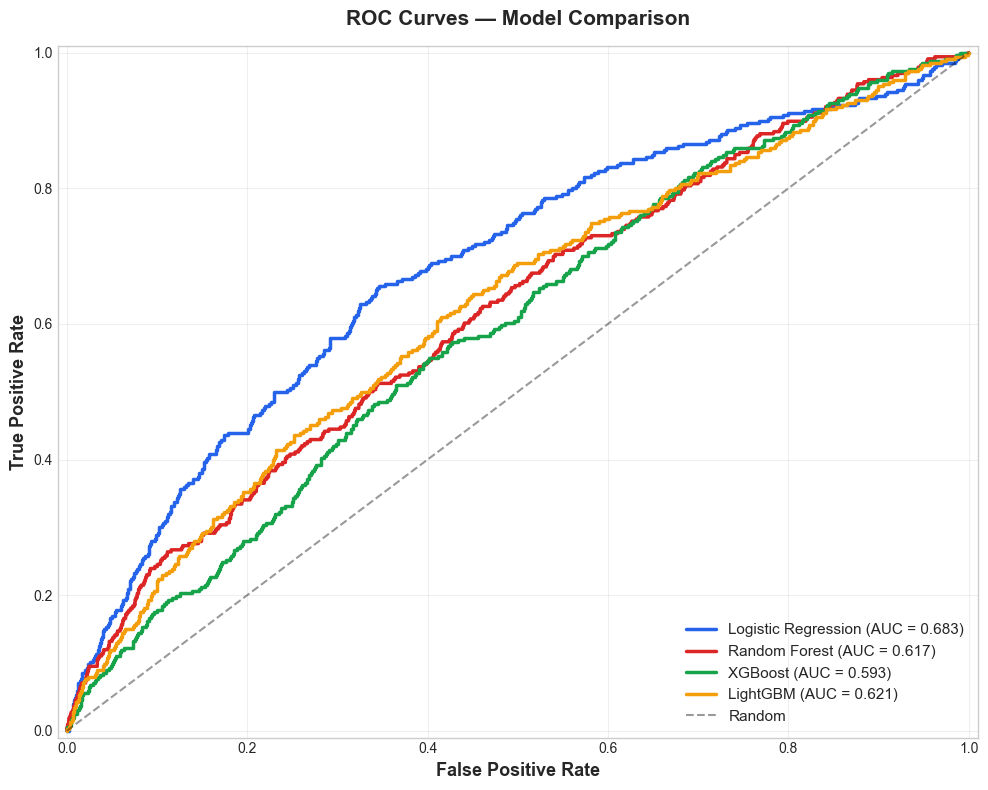

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  5a. ROC Curves — All Models
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(10, 8))

for i, (name, res) in enumerate(all_results.items()):
    if res.get('y_prob') is not None:
        fpr, tpr, _ = roc_curve(res['y_test'], res['y_prob'])
        auc_val = res['metrics']['roc_auc']
        ax.plot(
            fpr, tpr,
            label=f"{name} (AUC = {auc_val:.3f})",
            color=COLORS['models'][i % len(COLORS['models'])],
            linewidth=2.5,
        )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curves — Model Comparison', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(plots_dir, 'roc_curves_comparison.png'), dpi=150, bbox_inches='tight')
logger.info(f"  Saved: roc_curves_comparison.png")
plt.show()
plt.close(fig)

18:12:38 | INFO     |   Saved: precision_recall_curves.png


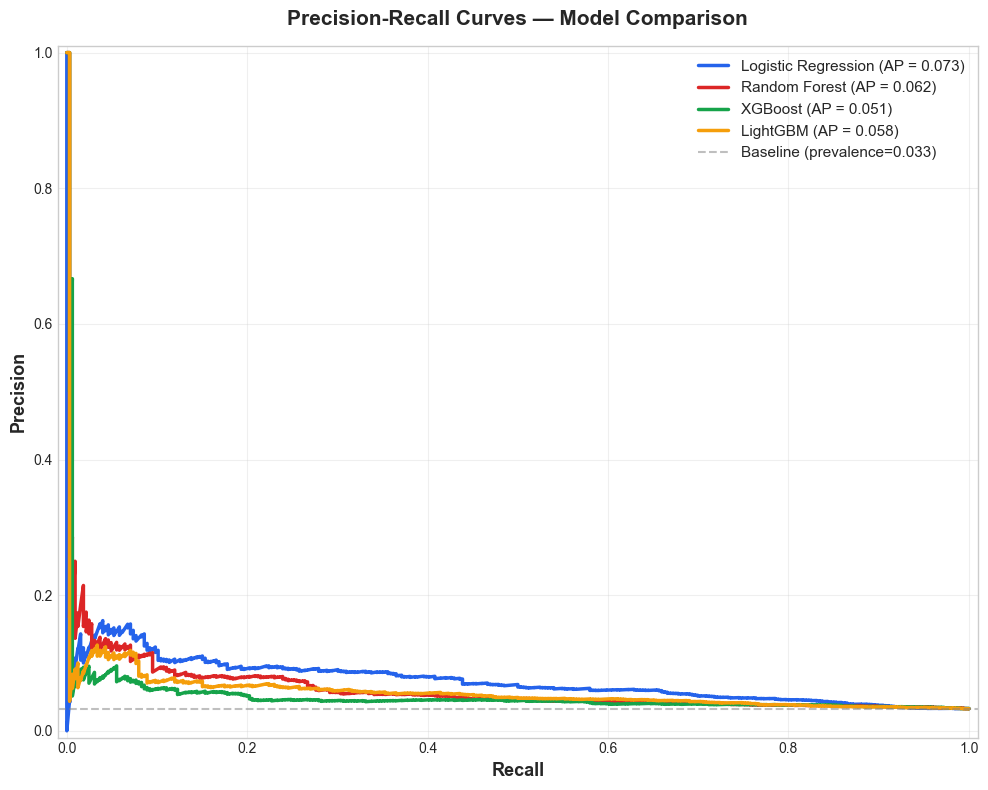

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  5b. Precision-Recall Curves — All Models
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(10, 8))

for i, (name, res) in enumerate(all_results.items()):
    if res.get('y_prob') is not None:
        prec_arr, rec_arr, _ = precision_recall_curve(res['y_test'], res['y_prob'])
        ap = res['metrics']['avg_precision']
        ax.plot(
            rec_arr, prec_arr,
            label=f"{name} (AP = {ap:.3f})",
            color=COLORS['models'][i % len(COLORS['models'])],
            linewidth=2.5,
        )

first_res  = next(iter(all_results.values()))
prevalence = np.mean(first_res['y_test'])
ax.axhline(
    y=prevalence, color='gray', linestyle='--', alpha=0.5,
    label=f'Baseline (prevalence={prevalence:.3f})',
)

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title('Precision-Recall Curves — Model Comparison', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(plots_dir, 'precision_recall_curves.png'), dpi=150, bbox_inches='tight')
logger.info(f"  Saved: precision_recall_curves.png")
plt.show()
plt.close(fig)

18:13:01 | INFO     |   Saved: model_comparison.png


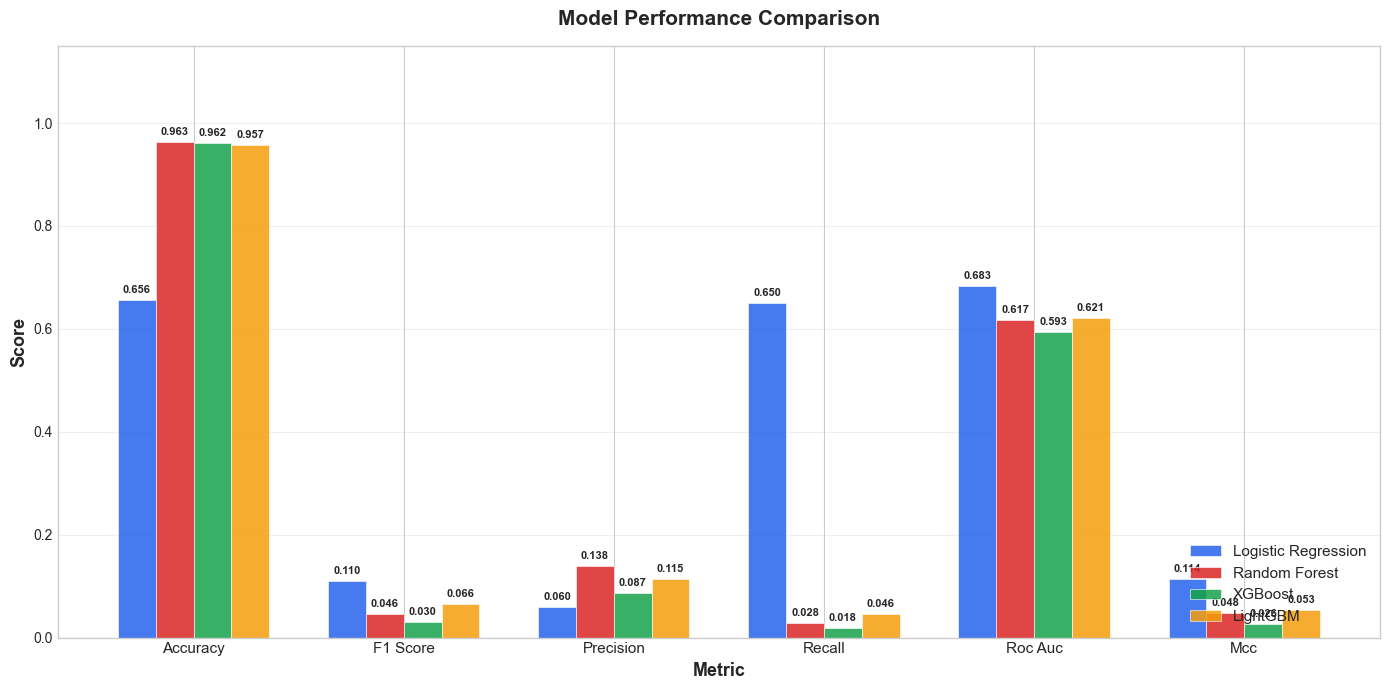

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  5c. Grouped Bar Chart — Model Comparison
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

metrics_to_show = ['accuracy', 'f1_score', 'precision', 'recall', 'roc_auc', 'mcc']

comparison_data = []
for name, res in all_results.items():
    for m in metrics_to_show:
        if m in res['metrics']:
            comparison_data.append({
                'Model' : name,
                'Metric': m.replace('_', ' ').title(),
                'Score' : res['metrics'][m],
            })

df_comp  = pd.DataFrame(comparison_data)
models   = list(all_results.keys())
x        = np.arange(len(metrics_to_show))
width    = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

for i, model_name in enumerate(models):
    model_data = df_comp[df_comp['Model'] == model_name]
    values     = model_data['Score'].values
    bars       = ax.bar(
        x + i * width, values, width,
        label=model_name,
        color=COLORS['models'][i % len(COLORS['models'])],
        alpha=0.85, edgecolor='white', linewidth=0.5,
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold',
        )

ax.set_xlabel('Metric', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_show], fontsize=11)
ax.legend(fontsize=11, loc='lower right', framealpha=0.9)
ax.set_ylim([0, 1.15])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(plots_dir, 'model_comparison.png'), dpi=150, bbox_inches='tight')
logger.info(f"  Saved: model_comparison.png")
plt.show()
plt.close(fig)

## 6. Save All Artifacts
Persist:
- Best model + all trained models (`.pkl`)
- Training results JSON (metrics, CV, params)
- Test predictions CSV (for dashboard)
- Training config, best-model metadata
- EDA data sample

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  SAVE ARTIFACTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

logger.info("\n" + "=" * 60)
logger.info("  SAVING ARTIFACTS")
logger.info("=" * 60)

artifacts_dir = TRAINING_CONFIG['artifacts_dir']

# ── 1. Best model ────────────────────────
model_path = os.path.join(artifacts_dir, 'best_model.pkl')
joblib.dump(best_model, model_path)
logger.info(f"   Best model ({best_model_name}): {model_path}")

# ── 2. All trained models ────────────────
for name, res in all_results.items():
    safe = name.replace(" ", "_").lower()
    path = os.path.join(artifacts_dir, f'model_{safe}.pkl')
    joblib.dump(res['model'], path)
    logger.info(f"  {name}: {path}")

# ── 3. Results JSON (no model objects) ───
results_serializable = {}
for name, res in all_results.items():
    results_serializable[name] = {
        'best_params': {
            k: (int(v) if isinstance(v, np.integer)
                 else float(v) if isinstance(v, np.floating) else v)
            for k, v in res['best_params'].items()
        },
        'metrics'          : res['metrics'],
        'cv_results'       : {k: {'mean': v['mean'], 'std': v['std']} for k, v in res['cv_results'].items()},
        'confusion_matrix' : res['confusion_matrix'],
        'threshold_result' : res['threshold_result'],
        'training_time'    : res['training_time'],
        'description'      : res['description'],
    }

results_path = os.path.join(artifacts_dir, 'training_results.json')
with open(results_path, 'w') as f:
    json.dump(results_serializable, f, indent=2, default=str)
logger.info(f"   Training results: {results_path}")

# ── 4. Test predictions CSV ──────────────
test_data = X_test.copy()
test_data['Actual'] = y_test.values if hasattr(y_test, 'values') else y_test
best_res = all_results[best_model_name]
test_data['Predicted'] = best_res['y_pred']
if best_res['y_prob'] is not None:
    test_data['Failure_Probability'] = best_res['y_prob']

test_path = os.path.join(artifacts_dir, 'test_predictions.csv')
test_data.to_csv(test_path, index=False)
logger.info(f"   Test predictions: {test_path}")

# ── 5. Training config ──────────────────
config_path = os.path.join(artifacts_dir, 'training_config.json')
with open(config_path, 'w') as f:
    json.dump(TRAINING_CONFIG, f, indent=2, default=str)
logger.info(f"   Training config: {config_path}")

# ── 6. Best model info ──────────────────
best_info = {
    'model_name'     : best_model_name,
    'primary_metric' : TRAINING_CONFIG['scoring_metric'],
    'best_score'     : best_score,
    'all_metrics'    : all_results[best_model_name]['metrics'],
    'best_params'    : results_serializable[best_model_name]['best_params'],
    'threshold'      : (
        all_results[best_model_name]['threshold_result']
        if all_results[best_model_name]['threshold_result']
        else {'best_threshold': 0.5}
    ),
    'feature_names'  : feature_names,
    'n_features'     : len(feature_names),
}
best_info_path = os.path.join(artifacts_dir, 'best_model_info.json')
with open(best_info_path, 'w') as f:
    json.dump(best_info, f, indent=2, default=str)
logger.info(f"   Best model info: {best_info_path}")

# ── 7. EDA data sample ──────────────────
eda_csv_path = os.path.join(artifacts_dir, 'eda_data.csv')
if os.path.exists(eda_csv_path):
    logger.info(f"   EDA data already exists: {eda_csv_path}")
else:
    logger.info(f"   EDA data not found — skipped (created by ETL notebook)")

18:15:01 | INFO     | 
18:15:01 | INFO     |   SAVING ARTIFACTS
18:15:01 | INFO     | ============================================================
18:15:01 | INFO     |    Best model (Logistic Regression): artifacts\best_model.pkl
18:15:01 | INFO     |   Logistic Regression: artifacts\model_logistic_regression.pkl
18:15:02 | INFO     |   Random Forest: artifacts\model_random_forest.pkl
18:15:02 | INFO     |   XGBoost: artifacts\model_xgboost.pkl
18:15:02 | INFO     |   LightGBM: artifacts\model_lightgbm.pkl
18:15:02 | INFO     |    Training results: artifacts\training_results.json
18:15:02 | INFO     |    Test predictions: artifacts\test_predictions.csv
18:15:02 | INFO     |    Training config: artifacts\training_config.json
18:15:02 | INFO     |    Best model info: artifacts\best_model_info.json
18:15:02 | INFO     |    EDA data already exists: artifacts\eda_data.csv
